# Comparing with Shapley Values

We want to find an example where on different replications of data $(X, y)$, the variability of Shapley values is larger due to the increased variability of $\hat{f}$ in extrapolated regions.



### Imports

In [33]:
import time
import os
import warnings

import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

from ale import ALE
from shapley import SHAP
from plots import plot_replication, plot_variability, get_full_bounding_box

# disable all warnings
warnings.filterwarnings("ignore")

In [34]:
from experiments import DGP, Experiment, RunConfig, ExplainerConfig
from models import (
    NNModelTuner, RFModelTuner,
    sample_X_gaussian, sample_X_uniform,
    signal_basic, signal_basic_interaction,
    signal_nonlinear, signal_nonlinear_interaction,
    signal_tricky_valley_rho_9, signal_tricky_valley_rho_99,
    signal_basic_explanation, signal_nonlinear_explanation,
)

# NOTE: change with attempt
signal = signal_tricky_valley_rho_9
true_explanation = None
true_explanation_y = None

N = 1000
SNR = 9
rng = np.random.default_rng(42)

dgp = DGP(
    snr=SNR,
    sample_X=sample_X_uniform(rho=0.95, scale=1),
    signal=signal,
)

# Tune hyperparameters on a single held-out replication, then fix for all replications.
# Best params are cached to disk; re-running this cell skips the search if already done.
X_tune, y_tune = dgp.sample(n=N, rng=rng)
nn_model = NNModelTuner(cv=5, n_iter=20, verbose=True, snr=SNR).tune(
    X_tune, y_tune, rng, dgp_slug=dgp.slug, n=N,
)

experiment = Experiment(
    dgp=dgp,
    fit_model=nn_model,
    dgp_slug=dgp.slug,
    fit_model_slug=nn_model.__name__,
    replications=20,
    n=N,
    save=True,
)

explainer_config = ExplainerConfig(K=50, L=20, centering="y", interpolate=True)
run_config = RunConfig(
    experiment=experiment,
    explainer_config=explainer_config,
)

[nn_cv] loaded cached params: {'solver': 'lbfgs', 'hidden_layer_sizes': (50,), 'alpha': 0.001, 'activation': 'relu'}


In [35]:
data_and_fitted_models = experiment.fit_models(rng)
bounding_box = get_full_bounding_box([d[0] for d in data_and_fitted_models])
x1_min, x1_max, x2_min, x2_max = bounding_box

In [36]:
# calculate correlation coefficient
print("Correlation coefficient:", np.mean([np.corrcoef(X[:, 0], X[:, 1]) for X, _, _ in data_and_fitted_models], axis=0)[0, 1])

Correlation coefficient: 0.9490728432098583


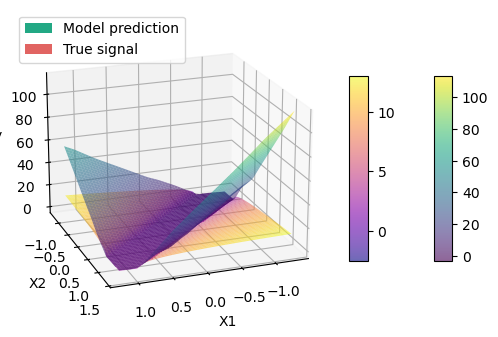

In [50]:
# Put in the figure!
plot_replication(experiment)

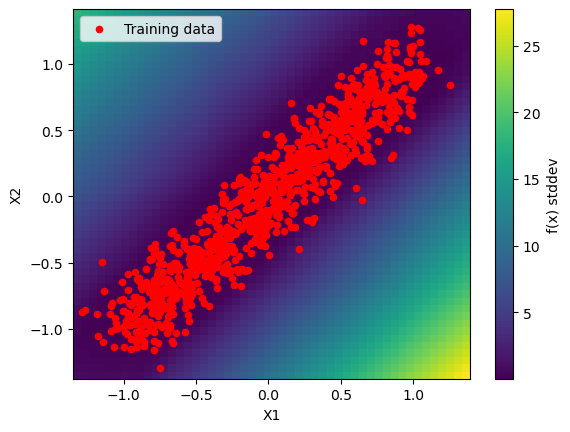

In [38]:
plot_variability(data_and_fitted_models, bounding_box)

(<Figure size 2100x500 with 4 Axes>,
 (<Axes: title={'center': 'Paths: X1 vs X2'}, xlabel='X1', ylabel='X2'>,
  <Axes: title={'center': 'Heatmap of wrapped_function'}, xlabel='X1', ylabel='X2'>,
  <Axes: title={'center': 'G-value curves for X1'}, xlabel='X1', ylabel='Centered g-value'>))

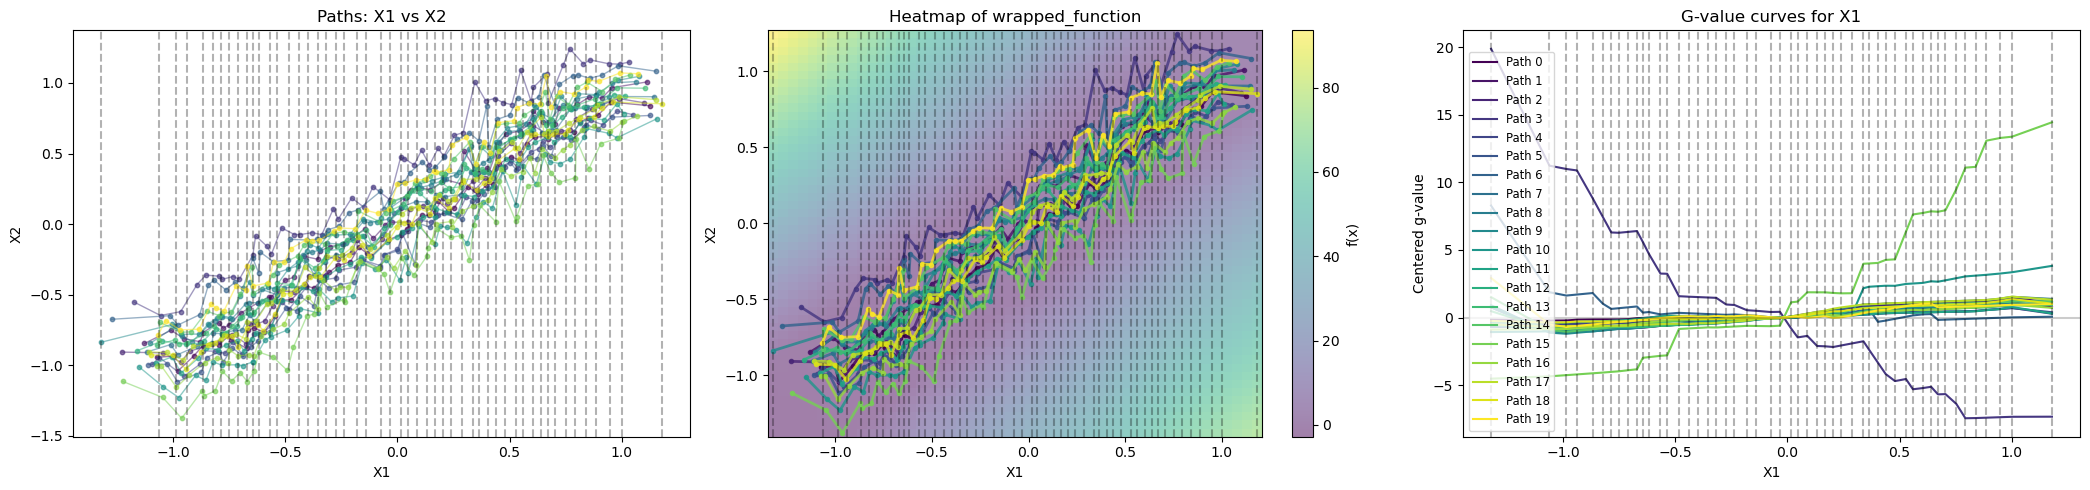

In [39]:
X, y = experiment.dgp.sample(1000, rng=np.random.default_rng(seed=42))
model = experiment.fit_model(X, y, rng=rng)
f = model.predict
ale = ALE(f, X, K=50, L=20, centering="x", verbose=False, interpolate=True)
ale.explain()
ale.plot_paths_summary(1, 2, cmap="viridis")

(<Figure size 2100x500 with 4 Axes>,
 (<Axes: title={'center': 'Paths: X2 vs X1'}, xlabel='X2', ylabel='X1'>,
  <Axes: title={'center': 'Heatmap of wrapped_function'}, xlabel='X2', ylabel='X1'>,
  <Axes: title={'center': 'G-value curves for X2'}, xlabel='X2', ylabel='Centered g-value'>))

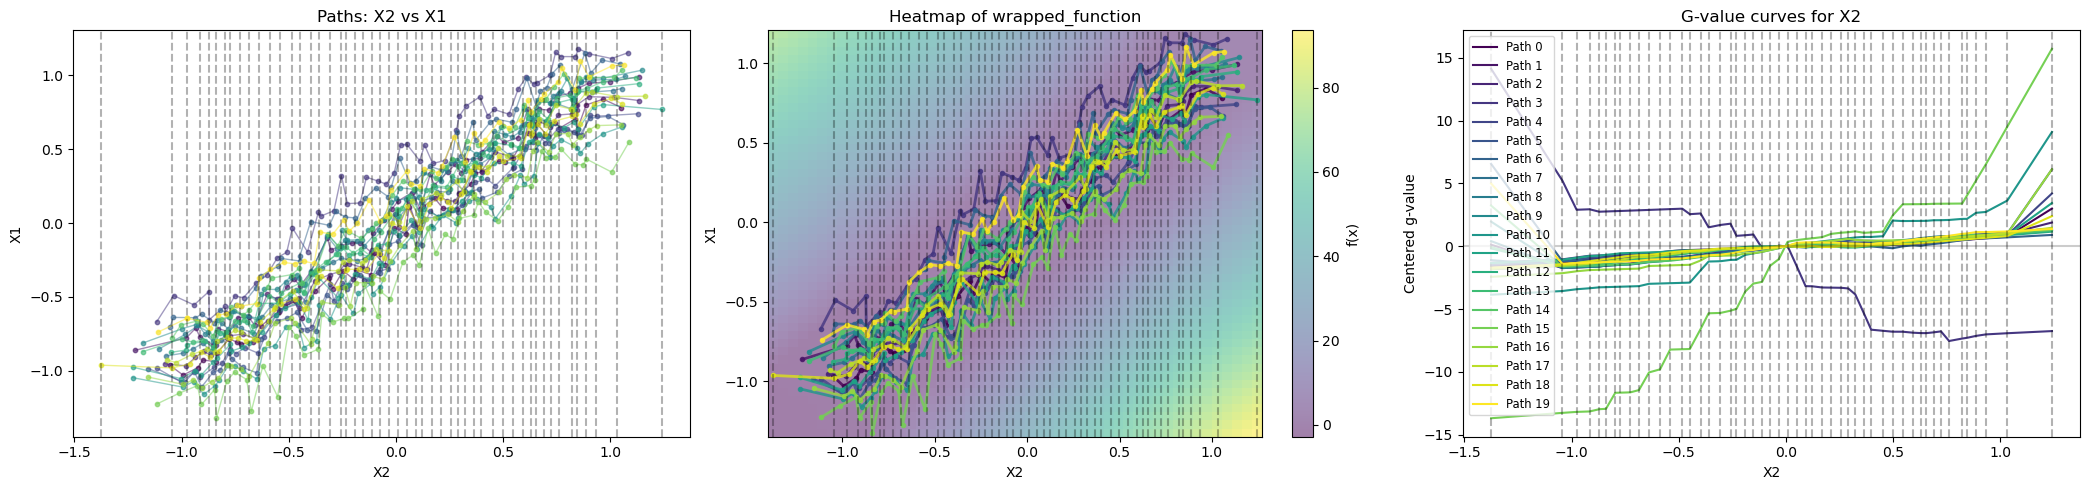

In [40]:
ale.plot_paths_summary(2, 1, cmap="viridis")

In [ ]:
# Sample explain_grid from the DGP
explain_grid = experiment.dgp.sample_X(n=experiment.n, rng=np.random.default_rng(99))

# Variability-visualization grid (cheap to recompute; used in cells below)
x1_lin = np.linspace(x1_min, x1_max, 50)
x2_lin = np.linspace(x2_min, x2_max, 50)
xx, yy = np.meshgrid(x1_lin, x2_lin)
var_grid = np.column_stack([xx.ravel(), yy.ravel()])

# Full (ALE + SHAP) cache — derive path from run_config so all tunable params are in the key.
# Uses a "full_" prefix to distinguish from the ALE-only cache written by run_config.run_ale().
_ale_cache_name = os.path.basename(run_config.cache_path(explain_grid))
cache_path = os.path.join("cached_explanations", _ale_cache_name.replace("ale_", "full_", 1))
print(cache_path)

if os.path.exists(cache_path):
    print("Loading cached results; skipping explanation generation...")
    cached = np.load(cache_path, allow_pickle=False)
    shap_exps              = cached["shap_exps"]                # (R, n_explain, d)
    f_vals                 = cached["f_vals"]                   # (R, n_explain)
    shap_globals           = cached["shap_globals"]             # (R,)
    shap_times             = cached["shap_times"]               # (R,)
    f_variability          = cached["f_variability"]            # (var_grid_size,)
    ale_queried_points     = cached["ale_queried_points"]       # (n_ale_query, d)
    shap_queried_points    = list(cached["shap_queried_points"])# list of (n_train, d)
    average_variability_shap = cached["average_variability_shap"]
    average_variability_ale  = float(cached["average_variability_ale"])

    # ALE has its own cache; reload from it
    ale_results = run_config.run_ale(explain_grid)
    ale_exps                   = ale_results["ale_exps"]
    ale_times                  = ale_results["ale_times"]
    ale_tree_construction_times = ale_results["ale_tree_times"]

else:
    print("Cache miss; generating explanations...")

    # ALE (has its own internal cache)
    ale_results = run_config.run_ale(explain_grid)
    ale_exps                   = ale_results["ale_exps"]
    ale_times                  = ale_results["ale_times"]
    ale_tree_construction_times = ale_results["ale_tree_times"]

    # Single-model ALE for queried-point visualization
    X, y = experiment.dgp.sample(experiment.n, rng=np.random.default_rng(seed=42))
    model = experiment.fit_model(X, y, rng=rng)
    f = model.predict
    ale = ALE(f, X, K=explainer_config.K, L=explainer_config.L, centering=explainer_config.centering,
              verbose=False, interpolate=True, knn_smooth=explainer_config.knn_smooth)
    ale.explain()
    ale_queried_points = ale.get_query_points()

    # Precompute SHAP background query points per explain_grid point (single model)
    shap_queried_points = []
    for i in range(explain_grid.shape[0]):
        shap = SHAP(f, X)
        shap.shim(explain_grid[i:i+1])
        shap_queried_points.append(shap.get_query_points())

    shap_queried_f = {i: [] for i in range(explain_grid.shape[0])}
    ale_queried_f  = []
    zz_f           = np.zeros((experiment.replications, var_grid.shape[0]))

    shap_exps    = []
    f_vals       = []
    shap_globals = []
    shap_times   = []

    for r in tqdm(range(experiment.replications), desc="SHAP replications"):
        rng = np.random.default_rng(42 + r)
        X, y, model = data_and_fitted_models[r]
        f = model.predict

        total_explained_points = explain_grid.shape[0] + X.shape[0]

        shapley = SHAP(f, X)
        t0 = time.perf_counter()
        shap_explanations = shapley.shim(explain_grid)
        shap_time = time.perf_counter() - t0

        for i in range(explain_grid.shape[0]):
            shap_queried_f[i].append(f(shap_queried_points[i]))
        ale_queried_f.append(f(ale_queried_points))

        shap_exps.append(shap_explanations)
        f_vals.append(f(explain_grid))
        shap_globals.append(0)
        shap_times.append(shap_time / total_explained_points)
        zz_f[r, :] = f(var_grid)

    shap_exps    = np.array(shap_exps)
    f_vals       = np.array(f_vals)
    shap_globals = np.array(shap_globals)
    shap_times   = np.array(shap_times)
    average_variability_shap = np.array([
        np.array(shap_queried_f[i]).std(axis=0).mean()
        for i in range(explain_grid.shape[0])
    ])
    average_variability_ale = float(np.array(ale_queried_f).std(axis=0).mean())
    f_variability = zz_f.std(axis=0)

    os.makedirs("cached_explanations", exist_ok=True)
    np.savez(
        cache_path,
        shap_exps=shap_exps,
        f_vals=f_vals,
        shap_globals=shap_globals,
        shap_times=shap_times,
        f_variability=f_variability,
        ale_queried_points=ale_queried_points,
        shap_queried_points=np.array(shap_queried_points),   # (n_explain, n_train, d)
        average_variability_shap=average_variability_shap,
        average_variability_ale=np.array(average_variability_ale),
    )

# --- Derived quantities — computed identically on cache hit or miss ---
_have_true = true_explanation is not None and true_explanation_y is not None
if _have_true:
    true_ale_exp  = true_explanation(explain_grid) if explainer_config.centering == "x" else true_explanation_y(explain_grid)
    true_shap_exp = true_explanation_y(explain_grid)
    ale_exps_bias  = (ale_exps.mean(axis=0) - true_ale_exp) ** 2
    shap_exps_bias = (shap_exps.mean(axis=0) - true_shap_exp) ** 2
else:
    ale_exps_bias  = np.zeros_like(ale_exps.mean(axis=0))
    shap_exps_bias = np.zeros_like(shap_exps.mean(axis=0))
ale_exps_std   = ale_exps.std(axis=0)
shap_exps_std  = shap_exps.std(axis=0)
f_vals_arr     = f_vals.std(axis=0)
ale_globals    = np.zeros(experiment.replications)

cached_explanations/full_sample_X_uniform_rho0.95_scale1_snr9_signal_tricky_valley_rho_9_nn_h50_relu_alpha0.001_lbfgs_n1000_R20_K50_L20_y_25370e2cd294.npz
Loading cached results; skipping explanation generation...


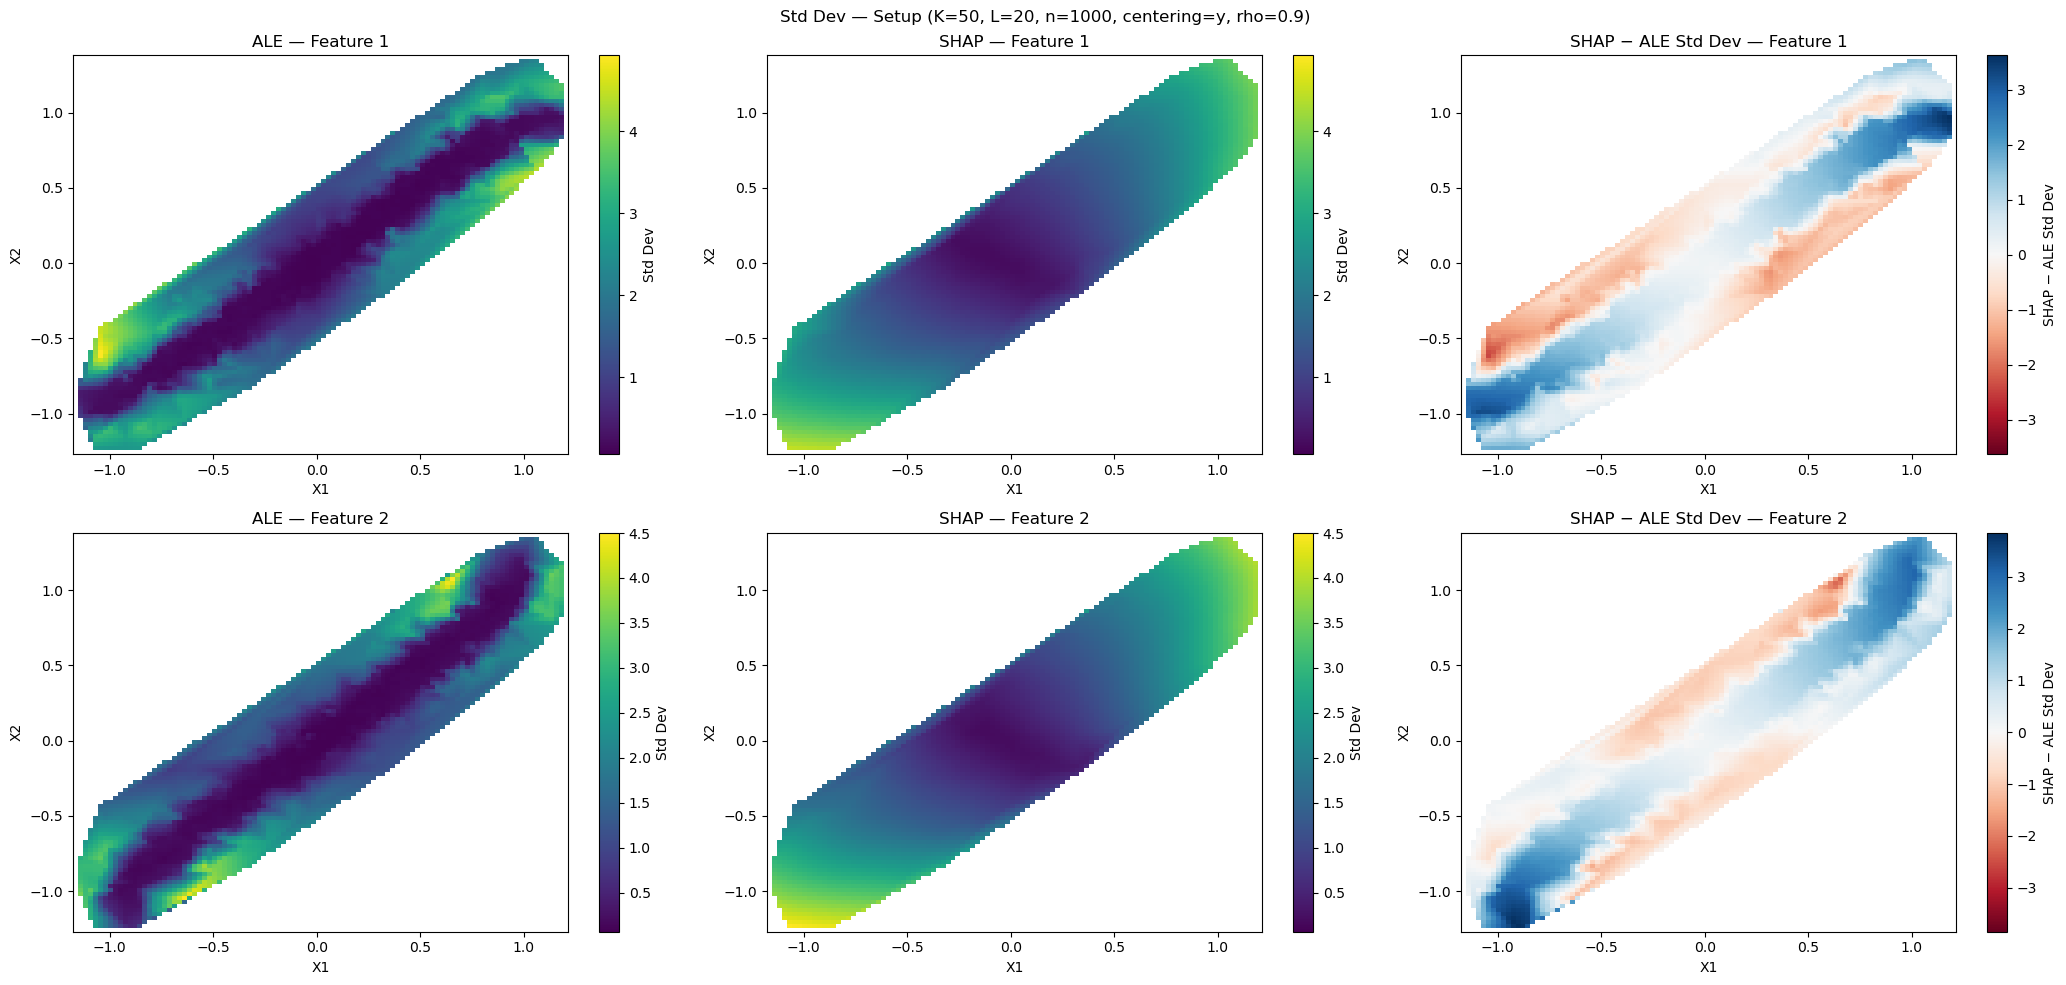

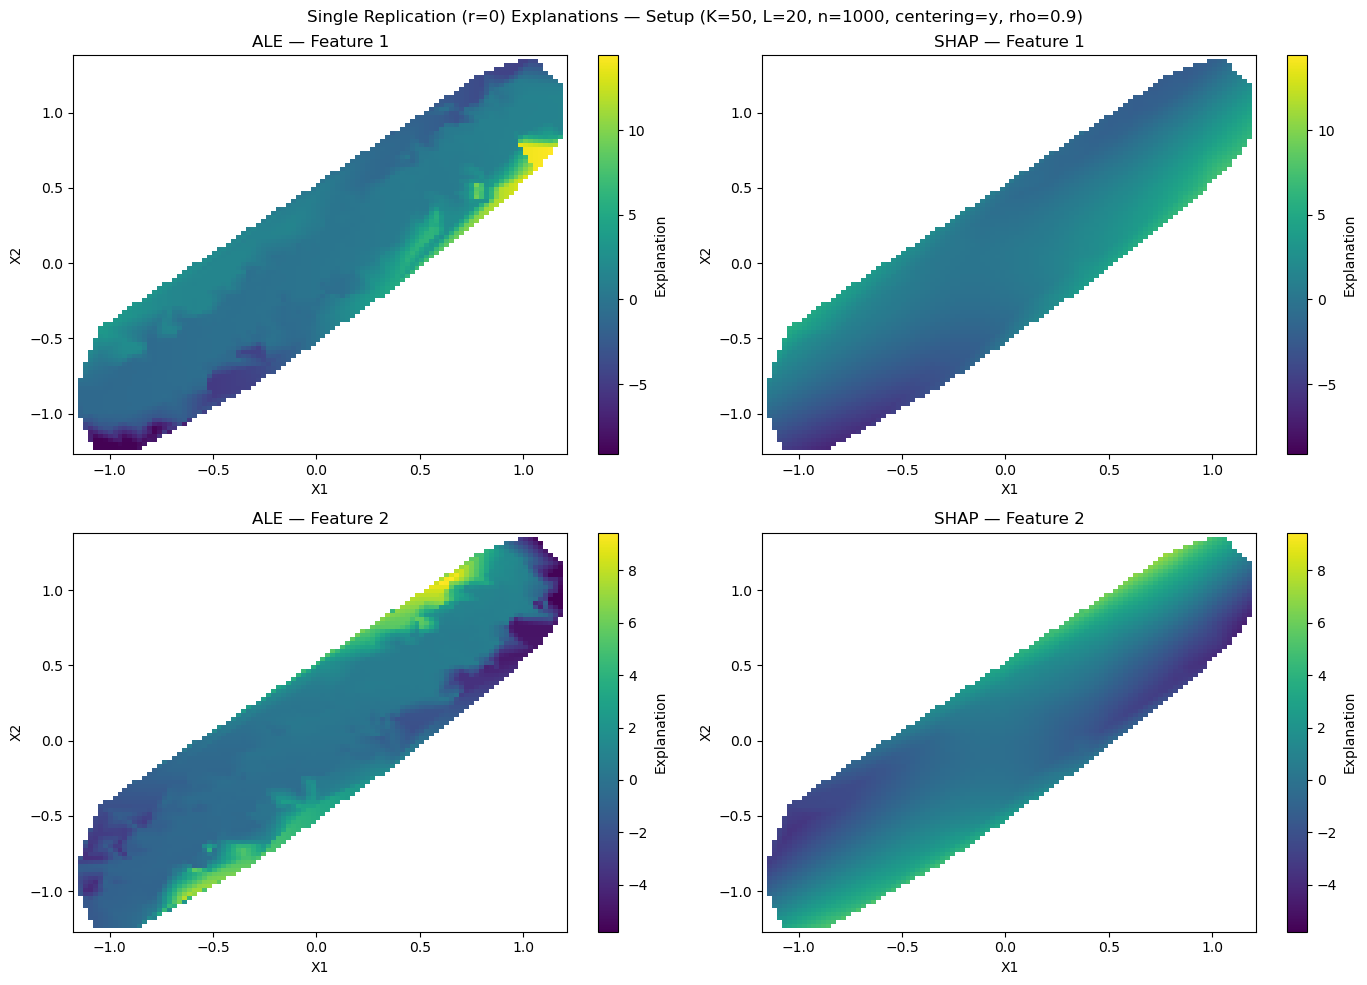

In [42]:
from scipy.interpolate import griddata

x1_pts = explain_grid[:, 0]
x2_pts = explain_grid[:, 1]

# Regular grid spanning the explain_grid range (not the full bounding box)
grid_res = 100
x1_grid = np.linspace(x1_pts.min(), x1_pts.max(), grid_res)
x2_grid = np.linspace(x2_pts.min(), x2_pts.max(), grid_res)
xx_hm, yy_hm = np.meshgrid(x1_grid, x2_grid)
extent = [x1_pts.min(), x1_pts.max(), x2_pts.min(), x2_pts.max()]

def to_heatmap(values):
    """Scatter -> regular grid; NaN outside the convex hull of explain_grid (griddata linear behavior)."""
    z = griddata(np.column_stack([x1_pts, x2_pts]), values, (xx_hm, yy_hm), method='linear')
    return np.ma.masked_invalid(z)

title = f"Setup (K={explainer_config.K}, L={explainer_config.L}, n={experiment.n}, centering={explainer_config.centering}, rho=0.9)"
if explainer_config.knn_smooth is not None and explainer_config.knn_smooth > 0:
    title += f", KNN Smoothing (k={explainer_config.knn_smooth})"

# --- Bias² heatmaps (only when true explanation is available) ---
if _have_true:
    fig, axes = plt.subplots(2, 3, figsize=(21, 10))
    fig.suptitle(f"Bias² — {title}")
    for feat_idx, feat_name in enumerate(["Feature 1", "Feature 2"]):
        ale_hm = to_heatmap(ale_exps_bias[:, feat_idx])
        shap_hm = to_heatmap(shap_exps_bias[:, feat_idx])
        vmin = min(ale_hm.min(), shap_hm.min())
        vmax = max(ale_hm.max(), shap_hm.max())
        for col, (hm, method) in enumerate([(ale_hm, "ALE"), (shap_hm, "SHAP")]):
            ax = axes[feat_idx, col]
            im = ax.imshow(hm, origin='lower', extent=extent, cmap='viridis',
                           vmin=vmin, vmax=vmax, aspect='auto')
            ax.set_xlabel("X1"); ax.set_ylabel("X2")
            ax.set_title(f"{method} — {feat_name}")
            fig.colorbar(im, ax=ax, label="Bias²")
        # Difference column: SHAP - ALE (positive = SHAP worse)
        diff_hm = shap_hm - ale_hm
        abs_max = np.nanmax(np.abs(diff_hm))
        ax = axes[feat_idx, 2]
        im = ax.imshow(diff_hm, origin='lower', extent=extent, cmap='RdBu',
                       vmin=-abs_max, vmax=abs_max, aspect='auto')
        ax.set_xlabel("X1"); ax.set_ylabel("X2")
        ax.set_title(f"SHAP − ALE Bias² — {feat_name}")
        fig.colorbar(im, ax=ax, label="SHAP − ALE Bias²")
    fig.tight_layout()
    plt.show()

# --- Std Dev heatmaps ---
fig, axes = plt.subplots(2, 3, figsize=(21, 10))
fig.suptitle(f"Std Dev — {title}")
for feat_idx, feat_name in enumerate(["Feature 1", "Feature 2"]):
    ale_hm = to_heatmap(ale_exps_std[:, feat_idx])
    shap_hm = to_heatmap(shap_exps_std[:, feat_idx])
    vmin = min(ale_hm.min(), shap_hm.min())
    vmax = max(ale_hm.max(), shap_hm.max())
    for col, (hm, method) in enumerate([(ale_hm, "ALE"), (shap_hm, "SHAP")]):
        ax = axes[feat_idx, col]
        im = ax.imshow(hm, origin='lower', extent=extent, cmap='viridis',
                       vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_xlabel("X1"); ax.set_ylabel("X2")
        ax.set_title(f"{method} — {feat_name}")
        fig.colorbar(im, ax=ax, label="Std Dev")
    # Difference column: SHAP - ALE (positive = SHAP worse)
    diff_hm = shap_hm - ale_hm
    abs_max = np.nanmax(np.abs(diff_hm))
    ax = axes[feat_idx, 2]
    im = ax.imshow(diff_hm, origin='lower', extent=extent, cmap='RdBu',
                   vmin=-abs_max, vmax=abs_max, aspect='auto')
    ax.set_xlabel("X1"); ax.set_ylabel("X2")
    ax.set_title(f"SHAP − ALE Std Dev — {feat_name}")
    fig.colorbar(im, ax=ax, label="SHAP − ALE Std Dev")
fig.tight_layout()
plt.show()

# --- Single replication explanations (replication 0) ---
single_ale = np.array(ale_exps)[0]
single_shap = np.array(shap_exps)[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Single Replication (r=0) Explanations — {title}")
for feat_idx, feat_name in enumerate(["Feature 1", "Feature 2"]):
    ale_hm = to_heatmap(single_ale[:, feat_idx])
    shap_hm = to_heatmap(single_shap[:, feat_idx])
    vmin = min(ale_hm.min(), shap_hm.min())
    vmax = max(ale_hm.max(), shap_hm.max())
    for col, (hm, method) in enumerate([(ale_hm, "ALE"), (shap_hm, "SHAP")]):
        ax = axes[feat_idx, col]
        im = ax.imshow(hm, origin='lower', extent=extent, cmap='viridis',
                       vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_xlabel("X1"); ax.set_ylabel("X2")
        ax.set_title(f"{method} — {feat_name}")
        fig.colorbar(im, ax=ax, label="Explanation")
fig.tight_layout()
plt.show()

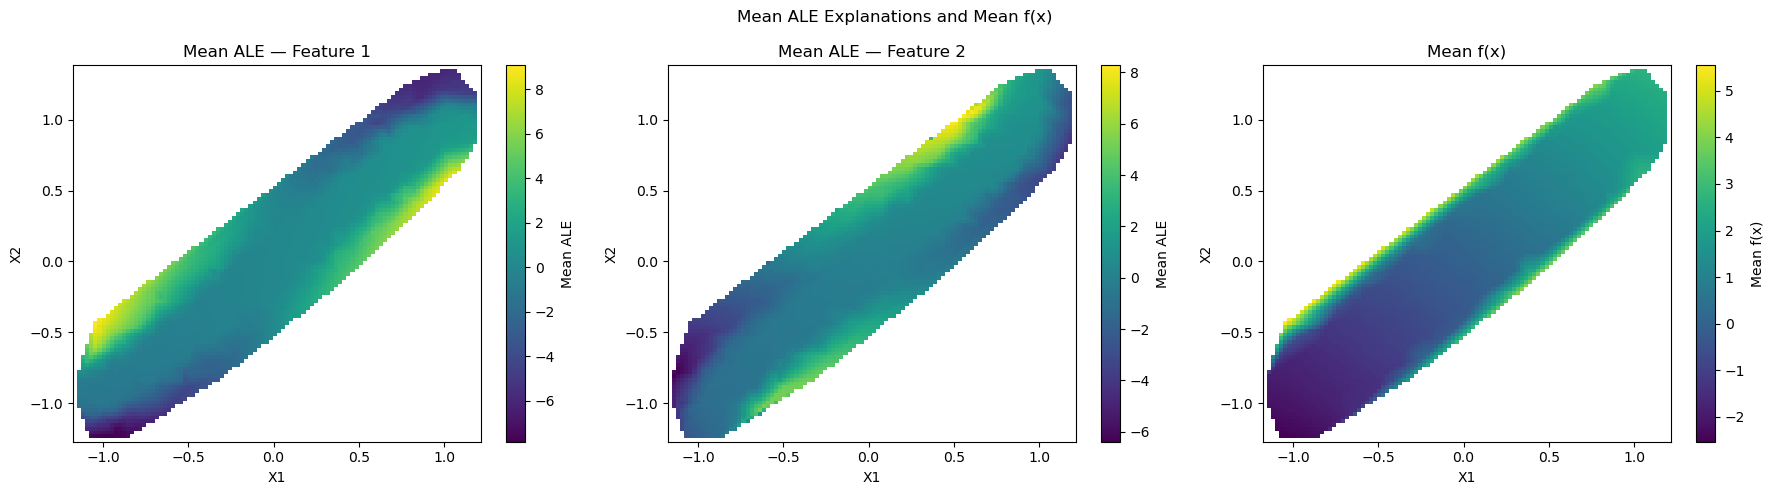

In [43]:
mean_ale_exps = np.array(ale_exps).mean(axis=0)
std_ale_exps = np.array(ale_exps).std(axis=0)
mean_f = np.array(f_vals).mean(axis=0)
std_f = np.array(f_vals).std(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Mean ALE Explanations and Mean f(x)")

f_hm = to_heatmap(mean_f)
im = axes[2].imshow(f_hm, origin='lower', extent=extent, cmap='viridis', aspect='auto')
axes[2].set_xlabel("X1"); axes[2].set_ylabel("X2"); axes[2].set_title("Mean f(x)")
fig.colorbar(im, ax=axes[2], label="Mean f(x)")

for feat_idx, feat_name in enumerate(["Feature 1", "Feature 2"]):
    ale_hm = to_heatmap(mean_ale_exps[:, feat_idx])
    ax = axes[feat_idx]
    im = ax.imshow(ale_hm, origin='lower', extent=extent, cmap='viridis', aspect='auto')
    ax.set_xlabel("X1"); ax.set_ylabel("X2")
    ax.set_title(f"Mean ALE — {feat_name}")
    fig.colorbar(im, ax=ax, label="Mean ALE")

fig.tight_layout()
plt.show()

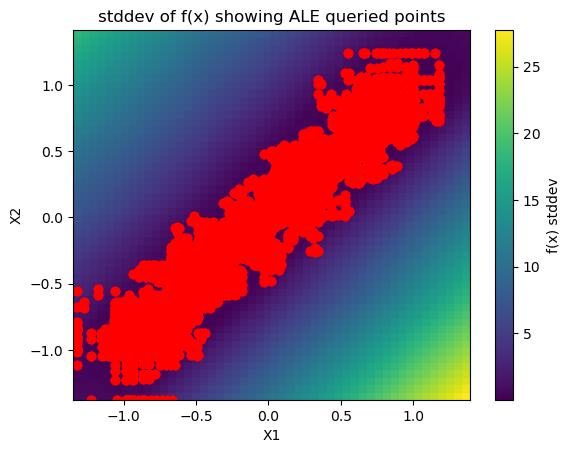

In [44]:
# plot variability
fig, ax = plt.subplots()
ax.scatter(ale_queried_points[:, 0], ale_queried_points[:, 1], c='red', label='ALE Queried Points')
im = ax.imshow(
    f_variability.reshape(xx.shape),
    origin="lower",
    extent=[x1_lin.min(), x1_lin.max(), x2_lin.min(), x2_lin.max()],
    cmap="viridis",
    aspect="auto",
)
ax.set_xlim([x1_lin.min(), x1_lin.max()])
ax.set_ylim([x2_lin.min(), x2_lin.max()])
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title("stddev of f(x) showing ALE queried points")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("f(x) stddev")

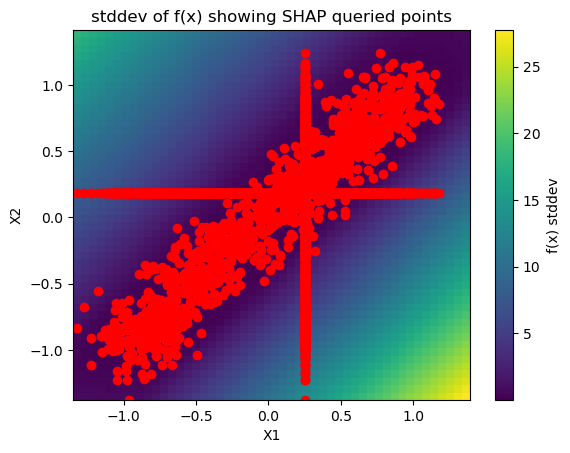

In [45]:
# plot variability with SHAP queried points (middle explain_grid point)
mid_idx = explain_grid.shape[0] // 2
fig, ax = plt.subplots()
ax.scatter(shap_queried_points[mid_idx][:, 0], shap_queried_points[mid_idx][:, 1], c='red', label='SHAP Queried Points')
im = ax.imshow(
    f_variability.reshape(xx.shape),
    origin="lower",
    extent=[x1_lin.min(), x1_lin.max(), x2_lin.min(), x2_lin.max()],
    cmap="viridis",
    aspect="auto",
)
ax.set_xlim([x1_lin.min(), x1_lin.max()])
ax.set_ylim([x2_lin.min(), x2_lin.max()])
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title("stddev of f(x) showing SHAP queried points")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("f(x) stddev")

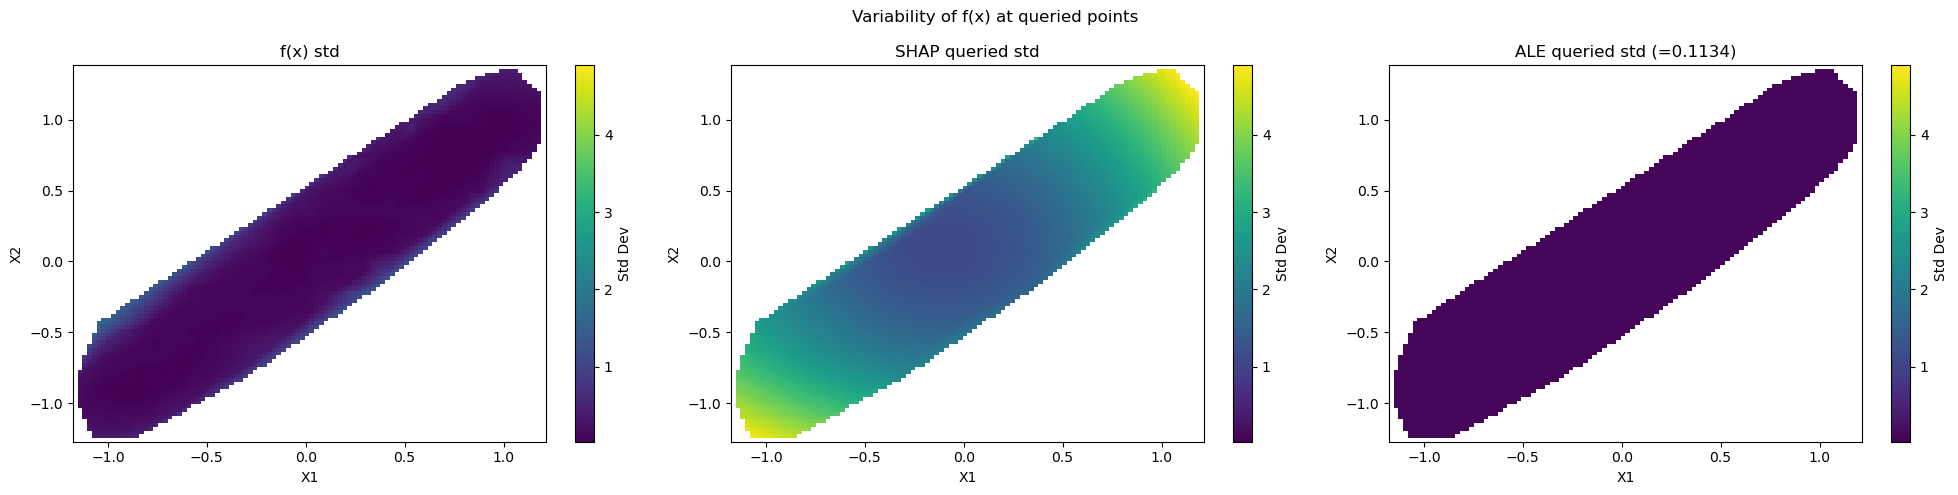

In [46]:
fv_hm = to_heatmap(f_vals_arr)
shap_var_hm = to_heatmap(average_variability_shap)
ale_var_hm = to_heatmap(np.full(explain_grid.shape[0], average_variability_ale))
vmin = min(fv_hm.min(), shap_var_hm.min(), ale_var_hm.min())
vmax = max(fv_hm.max(), shap_var_hm.max(), ale_var_hm.max())

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Variability of f(x) at queried points")

for ax, hm, label in zip(axes, [fv_hm, shap_var_hm, ale_var_hm],
                          ["f(x) std", "SHAP queried std", f"ALE queried std (={average_variability_ale:.4f})"]):
    im = ax.imshow(hm, origin='lower', extent=extent, cmap='viridis',
                   vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xlabel("X1"); ax.set_ylabel("X2"); ax.set_title(label)
    fig.colorbar(im, ax=ax, label="Std Dev")

fig.tight_layout()
plt.show()

In [47]:
# calculate global VIMs
print("ALE Global Means: ", ale_globals.mean(axis=0))
print("ALE Global Stddev: ", ale_globals.std(axis=0))
print("SHAP Global Means: ", shap_globals.mean(axis=0))
print("SHAP Global Stddev: ", shap_globals.std(axis=0))

ALE Global Means:  0.0
ALE Global Stddev:  0.0
SHAP Global Means:  0.0
SHAP Global Stddev:  0.0


In [48]:
print("ALE Average Time to Construct Tree: ", ale_tree_construction_times.mean())
print("ALE Average Time to Explain a Point: ", ale_times.mean())
print("SHAP Average Time to Explain a Point: ", shap_times.mean())

ALE Average Time to Construct Tree:  0.032134450050943994
ALE Average Time to Explain a Point:  1.4125929175133934e-05
SHAP Average Time to Explain a Point:  0.0002706549958260439
